In [2]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd
plt.style.use("fivethirtyeight")

In [21]:
class Perceptron:
  def __init__(self, eta, epochs):
    self.weights = np.random.randn(3) * 1e-4
    print(f"self.weights: {self.weights}")
    self.eta = eta
    self.epochs = epochs

  def activationFunction(self, inputs, weights):
    z = np.dot(inputs, weights)
    return np.where(z > 0 , 1, 0)

  def fit(self, X, y):
    self.X = X
    self.y = y

    X_with_bias = np.c_[self.X, -np.ones((len(self.X), 1))] # concactination
    print(f"X_with_bias: \n{X_with_bias}")

    for epoch in range(self.epochs):
      print(f"for epoch: {epoch}")
      y_hat = self.activationFunction(X_with_bias, self.weights)
      print(f"predicted value: \n{y_hat}")
      error = self.y - y_hat
      print(f"error: \n{error}")
      self.weights = self.weights + self.eta * np.dot(X_with_bias.T, error)
      print(f"updated weights: \n{self.weights}")
      print("#############\n")

  def predict(self, X):
    X_with_bias = np.c_[X, -np.ones((len(self.X), 1))]
    return self.activationFunction(X_with_bias, self.weights)

# AND Operator:

In [41]:
data = {"x1": [0,0,1,1], "x2": [0,1,0,1], "y": [0,0,0,1]}

AND = pd.DataFrame(data)
AND

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [42]:
X = AND.drop("y", axis=1)
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [43]:
y = AND['y']
y.to_frame()

,y
0,0
1,0
2,0
3,1


In [46]:
model = Perceptron(eta = 0.5, epochs=10)
model.fit(X,y)

self.weights: [6.42870131e-05 2.16575576e-05 4.80884353e-05]
X_with_bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
for epoch: 0
predicted value: 
[0 0 1 1]
error: 
0    0
1    0
2   -1
3    0
Name: y, dtype: int64
updated weights: 
[-4.99935713e-01  2.16575576e-05  5.00048088e-01]
#############

for epoch: 1
predicted value: 
[0 0 0 0]
error: 
0    0
1    0
2    0
3    1
Name: y, dtype: int64
updated weights: 
[6.42870131e-05 5.00021658e-01 4.80884353e-05]
#############

for epoch: 2
predicted value: 
[0 1 1 1]
error: 
0    0
1   -1
2   -1
3    0
Name: y, dtype: int64
updated weights: 
[-4.99935713e-01  2.16575576e-05  1.00004809e+00]
#############

for epoch: 3
predicted value: 
[0 0 0 0]
error: 
0    0
1    0
2    0
3    1
Name: y, dtype: int64
updated weights: 
[6.42870131e-05 5.00021658e-01 5.00048088e-01]
#############

for epoch: 4
predicted value: 
[0 0 0 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[6.42870131e-05 5.0002165

In [47]:
model.predict(X)

array([0, 0, 0, 1])

In [48]:
model.weights

array([6.42870131e-05, 5.00021658e-01, 5.00048088e-01])

# Saving and Loading Model

In [28]:
import os

# saving model
dir_ = "Perceptron_model"
os.makedirs(dir_, exist_ok=True)
filename = os.path.join(dir_, 'AND_model.model')
joblib.dump(model, filename)

['Perceptron_model\\AND_model.model']

In [29]:
# load the model from drive
loaded_model = joblib.load(filename)
result = loaded_model.predict(X)
print(result)

[0 0 0 1]


# OR Operation:

In [30]:
data = {"X1" : [0 ,0, 1, 1], "X2" : [0, 1, 0, 1], "y" : [0, 1, 1, 1]}

OR = pd.DataFrame(data)
OR

,X1,X2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [31]:
X = OR.drop("y", axis=1)
X

,X1,X2
0,0,0
1,0,1
2,1,0
3,1,1


In [33]:
y = OR['y']
y.to_frame()

,y
0,0
1,1
2,1
3,1


In [34]:
model = Perceptron(eta=0.5, epochs=10)
model.fit(X, y)

self.weights: [8.98099840e-05 9.02077328e-05 4.76949980e-06]
X_with_bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
for epoch: 0
predicted value: 
[0 1 1 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[8.98099840e-05 9.02077328e-05 4.76949980e-06]
#############

for epoch: 1
predicted value: 
[0 1 1 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[8.98099840e-05 9.02077328e-05 4.76949980e-06]
#############

for epoch: 2
predicted value: 
[0 1 1 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[8.98099840e-05 9.02077328e-05 4.76949980e-06]
#############

for epoch: 3
predicted value: 
[0 1 1 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[8.98099840e-05 9.02077328e-05 4.76949980e-06]
#############

for epoch: 4
predicted value: 
[0 1 1 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[8.98099840e-05 9.02077328e-05 

# X-OR Operation

In [35]:
data = {"X1" : [0, 0, 1, 1], "X2" : [0, 1, 0, 1], "y" : [0, 1, 1, 0]}
XOR = pd.DataFrame(data)
XOR

,X1,X2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [36]:
X = XOR.drop("y", axis=1)
X

,X1,X2
0,0,0
1,0,1
2,1,0
3,1,1


In [37]:
y = XOR['y']
y.to_frame()

,y
0,0
1,1
2,1
3,0


In [38]:
model = Perceptron(eta=0.5, epochs=10)
model.fit(X, y)

self.weights: [-0.00012658 -0.00018885 -0.00012693]
X_with_bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
for epoch: 0
predicted value: 
[1 0 1 0]
error: 
0   -1
1    1
2    0
3    0
Name: y, dtype: int64
updated weights: 
[-1.26577664e-04  4.99811148e-01 -1.26925460e-04]
#############

for epoch: 1
predicted value: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
updated weights: 
[-5.00126578e-01 -1.88852495e-04  9.99873075e-01]
#############

for epoch: 2
predicted value: 
[0 0 0 0]
error: 
0    0
1    1
2    1
3    0
Name: y, dtype: int64
updated weights: 
[-1.26577664e-04  4.99811148e-01 -1.26925460e-04]
#############

for epoch: 3
predicted value: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
updated weights: 
[-5.00126578e-01 -1.88852495e-04  9.99873075e-01]
#############

for epoch: 4
predicted value: 
[0 0 0 0]
error: 
0    0
1    1
2    1
3    0
Name: y, dtype: int64
updated weights: 
[-1.26577664e-04  4.99811148

# Analysis with the graph

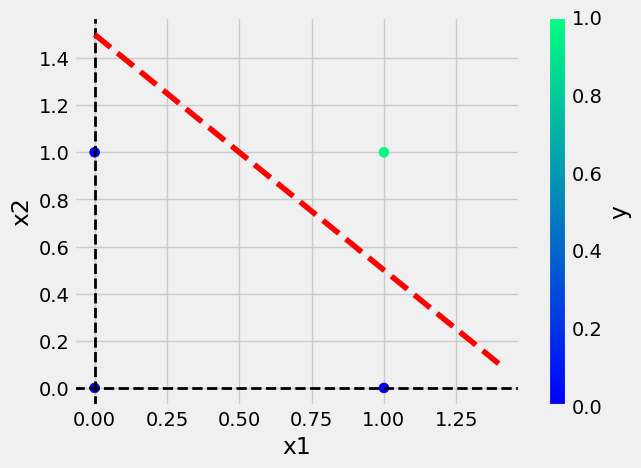

In [50]:
AND.plot(kind="scatter", x="x1", y="x2", c="y", s=50, cmap="winter")
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.axvline(x=0, color="black", linestyle="--", linewidth=2)

x = np.linspace(0, 1.4) # >>> 50
y = 1.5 - 1*np.linspace(0, 1.4) # >>> 50

plt.plot(x, y, "r--")

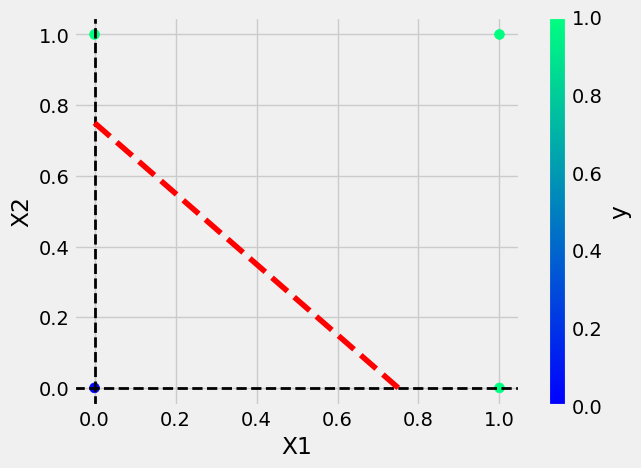

In [51]:
OR.plot(kind="scatter", x="X1", y="X2", c="y", s=50, cmap="winter")
plt.axhline(y = 0, color ="black", linestyle ="--", linewidth=2)
plt.axvline(x = 0, color ="black", linestyle ="--", linewidth=2)
plt.plot(np.linspace(0,0.75), 0.75 - 1*np.linspace(0,0.75), 'r--');

<Axes: xlabel='X1', ylabel='X2'>

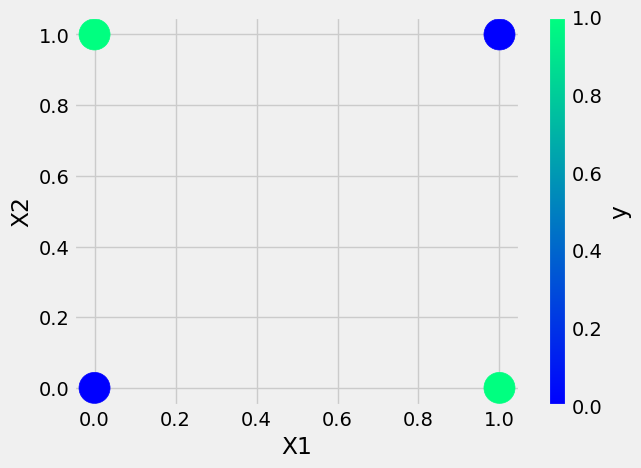

In [52]:
XOR.plot(kind="scatter", x="X1", y="X2", c="y", s=500, cmap="winter")